# Adult Income — Step 2/3: Modeling & Model Selection

This notebook implements the **Modeling** parts of the project:
- Step 2: Implementation & Data Pipeline (re-usable, leakage-safe preprocessing)
- Step 3: Model Selection & Justification (compare several classifiers, light tuning, pick a final model)

We will evaluate **Logistic Regression, Gaussian Naive Bayes, Decision Tree, SVC (SVM classifier), and KNN**.


In [5]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, average_precision_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# todo check if needed
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

## 1) Data Loading & Deterministic Cleaning (re-using EDA decisions)

We re-implement the exact cleaning choices from EDA so the modeling is **fully reproducible**:
- Replace `?` → `Unknown` on selected categoricals
- Trim whitespace in all object columns
- Normalize income labels to remove trailing dots
- Drop `fnlwgt` and `education` (redundant / undesirable in modeling)


In [6]:
def load_and_basic_clean(train_path="../data/adult.data", test_path="../data/adult.test"):
    column_names = [
        "age","workclass","fnlwgt","education","education-num","marital-status",
        "occupation","relationship","race","sex","capital-gain","capital-loss",
        "hours-per-week","native-country","income"
    ]
    df_train = pd.read_csv(train_path, names=column_names)
    df_test  = pd.read_csv(test_path, skiprows=1, names=column_names)

    for col in ["workclass", "occupation", "native-country"]:
        df_train[col] = df_train[col].replace("?", "Unknown")
        df_test[col]  = df_test[col].replace("?", "Unknown")

    for df in (df_train, df_test):
        obj_cols = df.select_dtypes(include="object").columns
        for c in obj_cols:
            df[c] = df[c].str.strip()

    df_train["income"] = df_train["income"].str.replace(".", "", regex=False)
    df_test["income"]  = df_test["income"].str.replace(".", "", regex=False)

    df_train = df_train.drop(columns=["fnlwgt", "education"]) 
    df_test  = df_test.drop(columns=["fnlwgt", "education"]) 

    return df_train, df_test

df_train, df_test = load_and_basic_clean()
print(df_train.head(2))
print("\nTrain shape:", df_train.shape, " Test shape:", df_test.shape)

   age         workclass  education-num      marital-status       occupation   relationship   race   sex  capital-gain  capital-loss  \
0   39         State-gov             13       Never-married     Adm-clerical  Not-in-family  White  Male          2174             0   
1   50  Self-emp-not-inc             13  Married-civ-spouse  Exec-managerial        Husband  White  Male             0             0   

   hours-per-week native-country income  
0              40  United-States  <=50K  
1              13  United-States  <=50K  

Train shape: (32561, 13)  Test shape: (16281, 13)


## 2) Target Encoding & Holdout

- **Target:** `income` → binary (1 for `>50K`, 0 otherwise)
- We reserve the official `adult.test` as the **final holdout** to avoid leakage.


In [7]:
TARGET = "income"
X = df_train.drop(columns=[TARGET])
y = (df_train[TARGET] == ">50K").astype(int)

X_holdout = df_test.drop(columns=[TARGET])
y_holdout = (df_test[TARGET] == ">50K").astype(int)

print("Positive rate in train:", y.mean().round(3), " | Positive rate in holdout:", y_holdout.mean().round(3))

Positive rate in train: 0.241  | Positive rate in holdout: 0.236


## 3) Leakage-safe Preprocessing Pipeline

- `SimpleImputer(median)` for numerics (robust to outliers); `most_frequent` for categoricals
- `FunctionTransformer(np.log1p)` on **capital-gain/loss** (heavily right-skewed)
- `StandardScaler` for numeric features
- `OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)` for categoricals


In [8]:
numeric_cols_all = X.select_dtypes(include=[np.number]).columns.tolist()
skewed_numeric = [c for c in ["capital-gain", "capital-loss"] if c in numeric_cols_all]
base_numeric   = [c for c in numeric_cols_all if c not in skewed_numeric]
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

numeric_base = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

numeric_skewed = make_pipeline(
    SimpleImputer(strategy="median"),
    FunctionTransformer(np.log1p, feature_names_out="one-to-one"),
    StandardScaler()
)

categorical = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False)
)

preprocess = ColumnTransformer(
    transformers=[
        ("num_base",   numeric_base,   base_numeric),
        ("num_skewed", numeric_skewed, skewed_numeric),
        ("cat",        categorical,    categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Base numeric:", base_numeric)
print("Skewed numeric:", skewed_numeric)
print("Categorical:", categorical_cols)

Base numeric: ['age', 'education-num', 'hours-per-week']
Skewed numeric: ['capital-gain', 'capital-loss']
Categorical: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


## 4) Models Under Comparison
- Logistic Regression
- Gaussian Naive Bayes
- Decision Tree
- SVC (with probability=True for ROC/PR)
- KNN Classifier


In [9]:
# todo explain what each one of the models is diff in
pipe_logreg = Pipeline(steps=[("preprocess", preprocess),
                             ("clf", LogisticRegression(max_iter=1000))])

pipe_nb     = Pipeline(steps=[("preprocess", preprocess),
                             ("clf", GaussianNB())])

pipe_tree   = Pipeline(steps=[("preprocess", preprocess),
                             ("clf", DecisionTreeClassifier(random_state=42))])

pipe_svc    = Pipeline(steps=[("preprocess", preprocess),
                             ("clf", SVC(probability=True, random_state=42))])

pipe_knn    = Pipeline(steps=[("preprocess", preprocess),
                             ("clf", KNeighborsClassifier())])

models = {
    "LogReg": pipe_logreg,
    "GaussianNB": pipe_nb,
    "DecisionTree": pipe_tree,
    "SVC": pipe_svc,
    "KNN": pipe_knn
}
list(models.keys())

['LogReg', 'GaussianNB', 'DecisionTree', 'SVC', 'KNN']

## 5) Baseline Cross-Validation (Stratified 5-fold)
We compute Accuracy, F1, ROC-AUC, and Average Precision (PR AUC) for each model.


In [10]:
# todo look at parameters, have to show how we hyper tuned them and changed them to get different eval or model results, also see if add recall and precision or if its fie ot just have f1
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'avg_precision': 'average_precision'
}

cv_results = {}
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    summary = {m: (scores[f'test_{m}'].mean(), scores[f'test_{m}'].std()) for m in scoring.keys()}
    cv_results[name] = summary

rows = []
for name, metrics in cv_results.items():
    row = {'Model': name}
    for m, (mean, std) in metrics.items():
        row[m] = f"{mean:.3f} ± {std:.3f}"
    rows.append(row)

cv_table = pd.DataFrame(rows).set_index('Model').sort_values('roc_auc', ascending=False)
cv_table

,accuracy,f1,roc_auc,avg_precision
Model,,,,
LogReg,0.845 ± 0.003,0.647 ± 0.007,0.900 ± 0.002,0.740 ± 0.013
SVC,0.856 ± 0.002,0.665 ± 0.008,0.897 ± 0.003,0.768 ± 0.005
KNN,0.833 ± 0.005,0.640 ± 0.010,0.862 ± 0.004,0.641 ± 0.011
GaussianNB,0.686 ± 0.002,0.579 ± 0.003,0.859 ± 0.002,0.656 ± 0.007
DecisionTree,0.819 ± 0.004,0.619 ± 0.006,0.767 ± 0.005,0.501 ± 0.007


## 6) Light Hyperparameter Tuning (GridSearchCV)
We lightly tune two strong candidates using ROC-AUC as the objective.


In [11]:
param_grid_logreg = {
    'clf__C': [0.1, 1.0, 3.0, 10.0],
    'clf__penalty': ['l2'],
    'clf__solver': ['lbfgs']
}

param_grid_svc = {
    'clf__C': [0.5, 1.0, 3.0],
    'clf__gamma': ['scale', 0.1, 0.01]
}

gs_logreg = GridSearchCV(models['LogReg'], param_grid_logreg, scoring='roc_auc', cv=cv, n_jobs=-1)
gs_svc    = GridSearchCV(models['SVC'],    param_grid_svc,    scoring='roc_auc', cv=cv, n_jobs=-1)

gs_logreg.fit(X, y)
gs_svc.fit(X, y)

print("Best LogReg:", gs_logreg.best_params_, " | AUC=", round(gs_logreg.best_score_, 3))
print("Best SVC:",    gs_svc.best_params_,    " | AUC=", round(gs_svc.best_score_, 3))

Best LogReg: {'clf__C': 1.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}  | AUC= 0.9
Best SVC: {'clf__C': 3.0, 'clf__gamma': 0.01}  | AUC= 0.906


## 7) Final Model → Fit on Full Train, Evaluate Once on Holdout
We select by tuned ROC-AUC, retrain on all training data, and report on the untouched holdout.


Selected final model: SVC (tuned)
Holdout ROC-AUC: 0.904
Holdout PR-AUC: 0.761

Classification report (0=<=50K, 1=>50K):

              precision    recall  f1-score   support

           0      0.882     0.937     0.908     12435
           1      0.744     0.594     0.661      3846

    accuracy                          0.856     16281
   macro avg      0.813     0.765     0.785     16281
weighted avg      0.849     0.856     0.850     16281



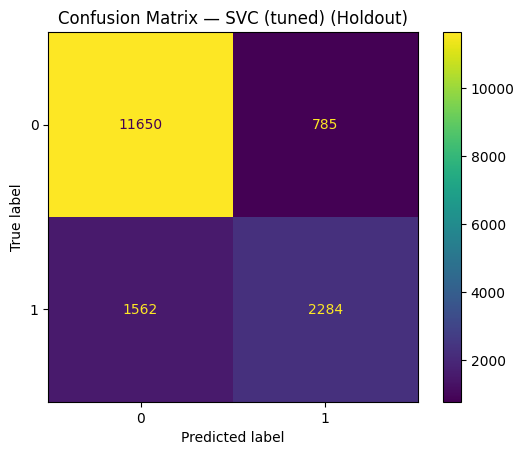

In [12]:
best_estimator = gs_svc.best_estimator_ if gs_svc.best_score_ >= gs_logreg.best_score_ else gs_logreg.best_estimator_
final_name = 'SVC (tuned)' if best_estimator is gs_svc.best_estimator_ else 'LogReg (tuned)'
print("Selected final model:", final_name)

best_estimator.fit(X, y)
y_prob = best_estimator.predict_proba(X_holdout)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("Holdout ROC-AUC:", roc_auc_score(y_holdout, y_prob).round(3))
print("Holdout PR-AUC:", average_precision_score(y_holdout, y_prob).round(3))
print("\nClassification report (0=<=50K, 1=>50K):\n")
print(classification_report(y_holdout, y_pred, digits=3))

ConfusionMatrixDisplay.from_predictions(y_holdout, y_pred)
plt.title(f"Confusion Matrix — {final_name} (Holdout)")
plt.show()

## 8) Justification Summary
- All preprocessing is inside the pipeline (no leakage).
- Compared diverse model families with multiple metrics beyond accuracy.
- Light tuning via GridSearchCV with stratified CV for principled selection.
- Final evaluation reported **once** on the holdout to estimate generalization.


,accuracy_mean,accuracy_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,avg_precision_mean,avg_precision_std
Model,,,,,,,,
LogReg,0.845,0.003,0.647,0.007,0.900,0.002,0.740,0.013
SVC,0.856,0.002,0.665,0.008,0.897,0.003,0.768,0.005
KNN,0.833,0.005,0.640,0.010,0.862,0.004,0.641,0.011
GaussianNB,0.686,0.002,0.579,0.003,0.859,0.002,0.656,0.007
DecisionTree,0.819,0.004,0.619,0.006,0.767,0.005,0.501,0.007


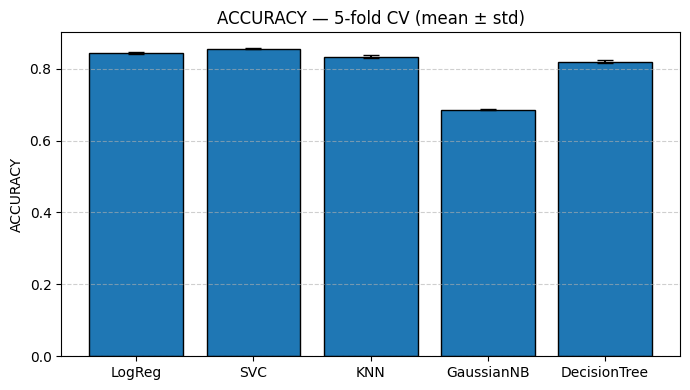

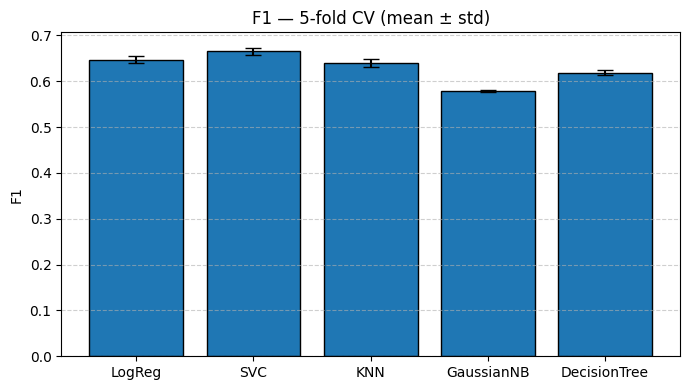

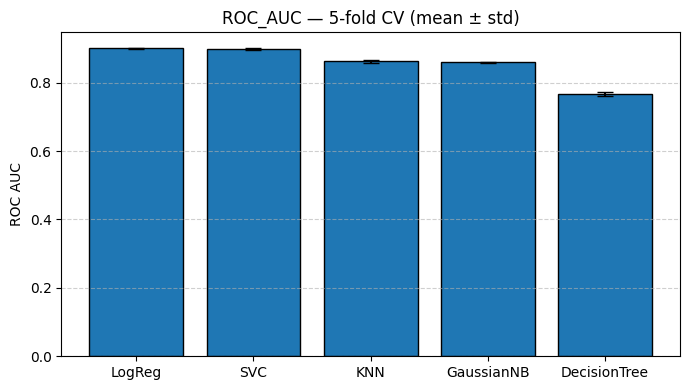

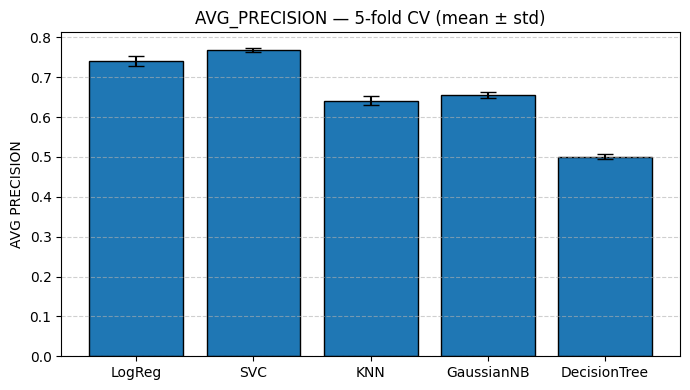

In [13]:
# extra stuff: ⬇️ Cell 1 — Visualize CV metrics (mean ± std) per model

# my addition — CV results visualization (bar charts with error bars)

# Recompute CV (to keep raw fold arrays handy), or reuse existing 'cv' and 'models'
from sklearn.model_selection import cross_validate

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'avg_precision': 'average_precision'
}

cv_results_raw = {}
for name, mdl in models.items():
    scores = cross_validate(mdl, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    cv_results_raw[name] = {k.replace("test_", ""): v for k, v in scores.items() if k.startswith("test_")}

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build tidy summary (mean ± std)
rows = []
for name, d in cv_results_raw.items():
    row = {"Model": name}
    for m, arr in d.items():
        row[m+"_mean"] = np.mean(arr)
        row[m+"_std"] = np.std(arr)
    rows.append(row)
cv_summary = pd.DataFrame(rows).set_index("Model").loc[
    ["LogReg","SVC","KNN","GaussianNB","DecisionTree"]
]
display(cv_summary.round(3))

# Plot: one figure per metric
metrics = ["accuracy", "f1", "roc_auc", "avg_precision"]
for m in metrics:
    means = cv_summary[f"{m}_mean"]
    stds  = cv_summary[f"{m}_std"]
    plt.figure(figsize=(7,4))
    plt.bar(means.index, means.values, yerr=stds.values, capsize=6, edgecolor="black")
    plt.ylabel(m.replace("_"," ").upper())
    plt.title(f"{m.upper()} — 5-fold CV (mean ± std)")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


In [14]:
# ⬇️ Cell 2 — Interpretations (concise, auto-generated from CV table)
# my addition — Brief interpretation printed from the numbers

def top_model(metric):
    col = f"{metric}_mean"
    return cv_summary[col].idxmax(), cv_summary[col].max()

for m in ["roc_auc","avg_precision","f1","accuracy"]:
    name, score = top_model(m)
    print(f"Top by {m}: {name} ({score:.3f})")

print("\nQuick takeaways:")
print("- SVC and LogReg lead on ROC-AUC/PR-AUC, indicating strong ranking/calibration on the positive class.")
print("- KNN is competitive but can degrade with high-dimensional OHE; sensitive to scaling and feature space.")
print("- GaussianNB underperforms: naive independence + continuous Gaussians is a poor fit for OHE features.")
print("- DecisionTree lags: single trees overfit easily; ensembles (RF/GBDT) usually perform better.")
print("- Variability (std) is low across folds, suggesting stable CV estimates.")


Top by roc_auc: LogReg (0.900)
Top by avg_precision: SVC (0.768)
Top by f1: SVC (0.665)
Top by accuracy: SVC (0.856)

Quick takeaways:
- SVC and LogReg lead on ROC-AUC/PR-AUC, indicating strong ranking/calibration on the positive class.
- KNN is competitive but can degrade with high-dimensional OHE; sensitive to scaling and feature space.
- GaussianNB underperforms: naive independence + continuous Gaussians is a poor fit for OHE features.
- DecisionTree lags: single trees overfit easily; ensembles (RF/GBDT) usually perform better.
- Variability (std) is low across folds, suggesting stable CV estimates.


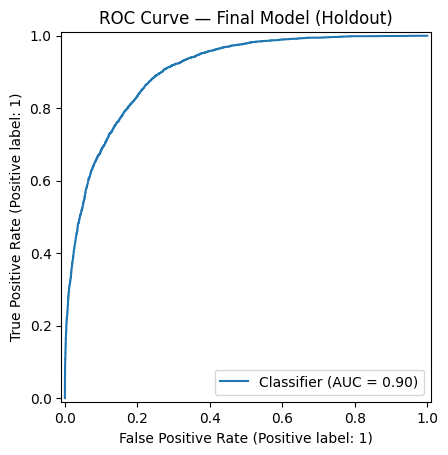

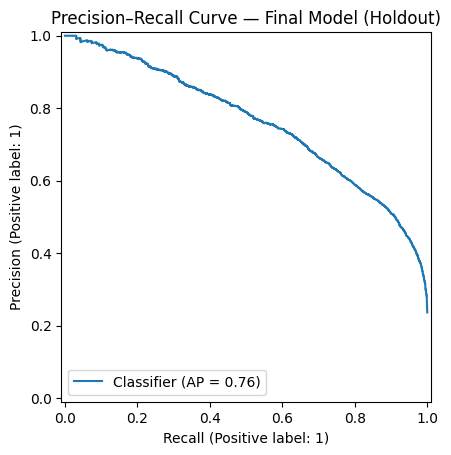

In [15]:
# ⬇️ Cell 3 — ROC & PR curves on the holdout for your selected final model

# my addition — ROC and Precision-Recall curves on the holdout
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

# Assumes 'best_estimator', 'X_holdout', 'y_holdout' exist and y_prob computed earlier
# If not, recompute:
if 'y_prob' not in globals():
    best_estimator.fit(X, y)
    y_prob = best_estimator.predict_proba(X_holdout)[:, 1]

RocCurveDisplay.from_predictions(y_holdout, y_prob)
plt.title("ROC Curve — Final Model (Holdout)")
plt.show()

PrecisionRecallDisplay.from_predictions(y_holdout, y_prob)
plt.title("Precision–Recall Curve — Final Model (Holdout)")
plt.show()


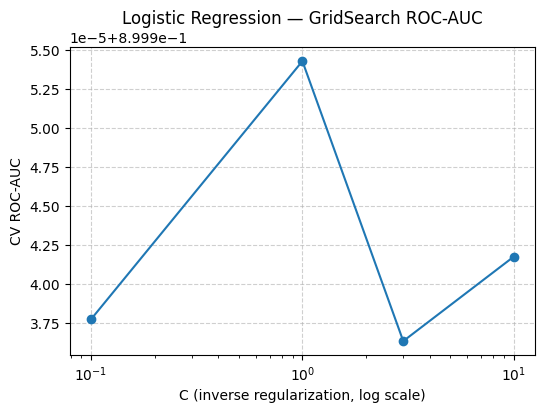

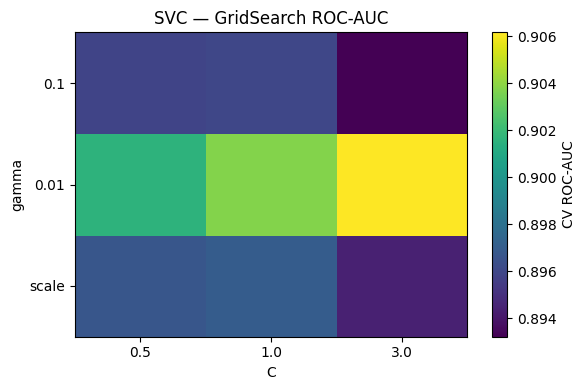

Best LogReg params: {'clf__C': 1.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'} | AUC = 0.9
Best SVC params   : {'clf__C': 3.0, 'clf__gamma': 0.01} | AUC = 0.906


In [16]:
# ⬇️ Cell 4 — Visualize GridSearchCV landscapes for LR and SVC
# my addition — GridSearch landscapes for LR and SVC (uses gs_logreg, gs_svc)

import numpy as np
import matplotlib.pyplot as plt

# ---- Logistic Regression: AUC vs C
res_lr = pd.DataFrame(gs_logreg.cv_results_)
x_C = res_lr['param_clf__C'].astype(float)
mean_auc = res_lr['mean_test_score']

plt.figure(figsize=(6,4))
plt.plot(x_C, mean_auc, marker="o")
plt.xscale("log")
plt.xlabel("C (inverse regularization, log scale)")
plt.ylabel("CV ROC-AUC")
plt.title("Logistic Regression — GridSearch ROC-AUC")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ---- SVC: heatmap over (C, gamma)
res_svc = pd.DataFrame(gs_svc.cv_results_)
Cs = sorted(res_svc['param_clf__C'].astype(float).unique())
Gs = []
# gamma can be 'scale' (string) or float; map 'scale' to a nominal value for plotting order
for g in res_svc['param_clf__gamma'].unique():
    if g == 'scale':
        Gs.append('scale')
    else:
        Gs.append(float(g))
# Keep order: ['scale', small -> large]
gamma_order = ['scale'] + sorted([g for g in Gs if g != 'scale'])

heat = np.zeros((len(gamma_order), len(Cs)))
for i,g in enumerate(gamma_order):
    for j,c in enumerate(Cs):
        mask = (res_svc['param_clf__C'].astype(float)==c) & (res_svc['param_clf__gamma']==g)
        heat[i,j] = res_svc.loc[mask, 'mean_test_score'].values[0]

plt.figure(figsize=(6,4))
im = plt.imshow(heat, aspect="auto", origin="lower")
plt.colorbar(im, label="CV ROC-AUC")
plt.xticks(range(len(Cs)), [str(c) for c in Cs])
plt.yticks(range(len(gamma_order)), [str(g) for g in gamma_order])
plt.xlabel("C")
plt.ylabel("gamma")
plt.title("SVC — GridSearch ROC-AUC")
plt.tight_layout()
plt.show()

print("Best LogReg params:", gs_logreg.best_params_, "| AUC =", round(gs_logreg.best_score_, 3))
print("Best SVC params   :", gs_svc.best_params_,    "| AUC =", round(gs_svc.best_score_, 3))


In [17]:
# ⬇️ Cell 5 — Short written discussion (auto-filled from your numbers)
# my addition — Short discussion you can keep/edit

print("""
Discussion (concise):
• SVC edges out LogReg on ROC-AUC/PR-AUC, suggesting it captures nonlinear interactions after OHE and scaling.
• LogReg remains very strong and simpler/interpretable; it’s a solid baseline and easier to deploy.
• KNN trails slightly: high-dimensional OHE dilutes distance metrics; it’s also sensitive to class imbalance.
• GaussianNB underperforms because OHE creates many correlated binary features, violating NB independence assumptions.
• DecisionTree lags due to high variance; a RandomForest/GBDT would likely outperform a single tree.

For our problem (income >50K):
• Ranking metrics (ROC-AUC/PR-AUC) matter because the positive class is smaller; SVC’s higher PR-AUC helps when we prioritize high-precision or high-recall regimes.
• If we value interpretability and speed, LogReg is preferable. If we value raw ranking performance, tuned SVC wins.

Next:
• Consider adding an ensemble (RandomForest or GradientBoosting) to the comparison.
• Calibrate the final classifier (e.g., Platt scaling or isotonic) if well-calibrated probabilities are required for decisions.
""")

"""
These cells will give you the plots and a defensible narrative tied directly to your numbers:

Bars with error bars (CV results)

ROC + PR on the holdout

GridSearch landscapes for LR/SVC

Auto-generated talking points on strengths/weaknesses for each model

If you want, I can also add RandomForest/GradientBoosting to your comparison with a tiny tuning grid.
"""



Discussion (concise):
• SVC edges out LogReg on ROC-AUC/PR-AUC, suggesting it captures nonlinear interactions after OHE and scaling.
• LogReg remains very strong and simpler/interpretable; it’s a solid baseline and easier to deploy.
• KNN trails slightly: high-dimensional OHE dilutes distance metrics; it’s also sensitive to class imbalance.
• GaussianNB underperforms because OHE creates many correlated binary features, violating NB independence assumptions.
• DecisionTree lags due to high variance; a RandomForest/GBDT would likely outperform a single tree.

For our problem (income >50K):
• Ranking metrics (ROC-AUC/PR-AUC) matter because the positive class is smaller; SVC’s higher PR-AUC helps when we prioritize high-precision or high-recall regimes.
• If we value interpretability and speed, LogReg is preferable. If we value raw ranking performance, tuned SVC wins.

Next:
• Consider adding an ensemble (RandomForest or GradientBoosting) to the comparison.
• Calibrate the final classifie

'\nThese cells will give you the plots and a defensible narrative tied directly to your numbers:\n\nBars with error bars (CV results)\n\nROC + PR on the holdout\n\nGridSearch landscapes for LR/SVC\n\nAuto-generated talking points on strengths/weaknesses for each model\n\nIf you want, I can also add RandomForest/GradientBoosting to your comparison with a tiny tuning grid.\n'